In [1]:
#SCALAR GAUSS BONNET MODIFIED EXAMPLE

# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

#____________________________________________________________________________________

# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/source')

from initialdata.bhinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 96.0 # outer edge of the grid (including ghosts)
#min_dr = 1 / 16 # roughly 32 points across the BH

min_dr = 1/16
#min_dr = 1 / 64
max_dr = 2

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)

# Get initial state
initial_state_HR = get_initial_state(grid_HR, background_HR)


#____________________________________________________________________________________
# for control of time integrator and spatial grid
#T = 10 # Maximum evolution time
T = 4
#num_points_t = 128 # time resolution (only for outputs, not for integration, which is decided by python)
num_points_t = 250

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requested
solution = dense_solution.sol(t).T

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}
{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 275}


  0%|          | 0/1000 [00:00<?, ?‰/s]

# Comparison of Scaled vs Non Scaled

In [2]:
idx= -1 # time index

AA = Capital[idx]
aa = Lowercase[idx]


plt.plot(r,AA, label='Capital', linestyle='-')
plt.plot(r,aa, label = 'Lowercase', linestyle="--")


plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')

plt.xlim(0,1)
plt.ylim(-50,50)
plt.grid()

IndexError: list index out of range

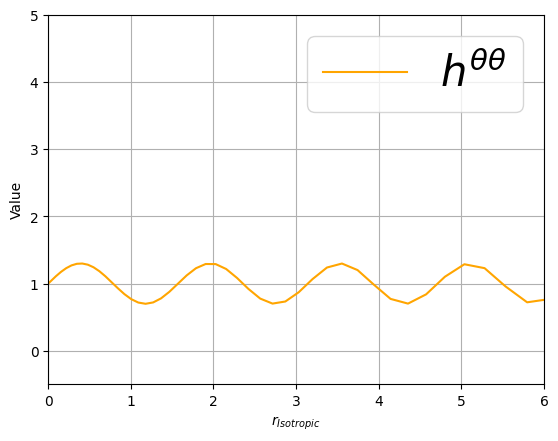

In [11]:
idx= -1 # time index

'''AA = Capital[idx]
aa = Lowercase[idx]'''

# = s_{ij} h_{ij}


#plt.plot(r,((np.sin(4*r))* r**-2)+1, label=r'$\epsilon^{\theta\theta} $', linestyle='-')
plt.plot(r,0.3*np.sin(4*r)+1, label=r'$h^{\theta\theta}$', linestyle='-', color='orange')



plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best', fontsize=30)

plt.xlim(0,6)
plt.ylim(-0.5,5)
plt.grid()
plt.savefig('lower')